# Contextualized embedding with transformer models illustrated

In this notebook, we begin to peek under the hood of a BERT transformer model to understand how contextualized embedding work.
We then also introduce a couple of potential use cases that leverage contextualized embeddings.

<br>
<a target="_blank" href="https://colab.research.google.com/github/haukelicht/advanced_text_analysis/blob/main/notebooks/embedding/contextualized_embedding_transformers_explained.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Note:** If running on Google Colab, make sure to use a GPU runtime (go to Runtime > Change runtime type, select "T4 GPU", and click save). See [this guide](https://github.com/haukelicht/advanced_text_analysis/blob/main/setup/setup_colab_runtime.md).

### Setup

#### Colab

In [1]:
# check if on colab
COLAB = True
try:
    import google.colab
except:
    COLAB=False

if COLAB:
    # shallow clone of current state of main branch 
    !git clone --branch main --single-branch --depth 1 --filter=blob:none https://github.com/haukelicht/advanced_text_analysis.git

    %pip install -q umap-learn~=0.5.12


#### Required packages

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM

from bertviz import head_view
from bertviz.transformers_neuron_view import BertModel as BertVizModel 
from bertviz.transformers_neuron_view import BertTokenizer as BertVizTokenizer
from bertviz.neuron_view import show

import umap
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

### Some terminology

Here are the most important peices of the transformer model we will work wit:

- `model()` -- this _is_ the model (has been pre-trained, we only use it to compute contextualized embeddings)
- `tokenizer()` -- this is the tokenizer associated with the model that converts raw texts into sequences of token IDs that point tot the corresponding tokens' location in the model's input embedding matrix
- `outputs` -- this is what the model _outputs_ when we process an input sentence through it
-  `outputs.hidden_states` -- these are the contextualized embeddings prodcued at each layer
-  `outputs.last_hidden_state` -- this is the contextualized embeddings at the _final_ layer


## Intro to the `transformers` library

In python, the standard library to work with transformer models is `transformers`.
It provides access to pre-trained transformers models through its [model hub]().
The `transformers` library is developed and maintained by Hugging Face Inc.

### pre-trained models and tokenizers

To use a pre-trained model for embedding texts, we need two things:

1. the model's tokenizer
1. and of course the model itself

We use the model to process a text though its **layers** to obtain the text's **embedding**.
But to be able to do this, we need to **tokenize** the text to convert it into number – because deep neural network can only process with numbers, not with raw text.

Below we load a pre-trained BERT model, specifically "bert-base-uncased", which is a smallish version of BERT (hence 'base' instead of 'large') that does not distinguish between upper- and lowercase letters (hence 'uncased'). 

In [3]:
# define the name of the model we want to load
model_id = 'google-bert/bert-base-uncased'

# load the pre-trained model and tokenizer 
model = autoModel.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id)
# NOTE: this will trigger downloading the model and tokenizer if you haven't done so before

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [25]:
# let'S switch into "evaluation" mode because we are not training the model and only want to use it for inference
model.eval();

Let's get some information about the model by looking at its configuration attribute (`config`):

In [ ]:
# let's get some important information about the model
print('vocabulary size:', model.config.vocab_size)
print('embedding dimensionality:', model.config.hidden_size)
print('number of layers:', model.config.num_hidden_layers)

embedding dimensionality: 768
number of layers: 12
vocabulary size: 30522


::: {.callout-note title="Interpretation"}

The model 

- can represent words with 30522 unique tokens (its vocabulary)
- represent each token with a vector of 768 dimensions
- each text is processed through 12 layers of the BERT model that progressively contextualize the token representations

:::

In [5]:
# lets' have a look at the model architecture
print(model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
            (dropout): Dropout(p=

- the models first component is a `BertEmbeddings` module that contains
    1. the initial word embedding layer
    2. the positional embedding
- after this we have the `BertEncoder` module that consists of 12 `BertLayer`s

If we just want to get the initial word embeddings, we can access them like this.

In [6]:
model.embeddings.word_embeddings.weight.shape

torch.Size([30522, 768])

::: {.callout-note title="word embedding weights shape"}

The shape of the word embedding weights matrix is `(vocabulary size, embedding dimensionality)`, which in this case is `(30522, 768)`.

:::

In [7]:
print(model.embeddings.word_embeddings)

# let's get the first five values of the first embedding
model.embeddings.word_embeddings.weight[0][:5].detach().numpy()

Embedding(30522, 768, padding_idx=0)


array([-0.01018257, -0.06154883, -0.02649689, -0.0420608 ,  0.00116716],
      dtype=float32)

In [46]:
# print the layers
for i, layer in enumerate(model.encoder.layer):
    print(f"layer {i:02d}: {layer.__class__.__name__}")

layer 00: BertLayer
layer 01: BertLayer
layer 02: BertLayer
layer 03: BertLayer
layer 04: BertLayer
layer 05: BertLayer
layer 06: BertLayer
layer 07: BertLayer
layer 08: BertLayer
layer 09: BertLayer
layer 10: BertLayer
layer 11: BertLayer


In [40]:
# get the last layer
last_layer = dict(model.encoder.layer[-1].named_parameters())
print(f"Components of the last layer:\n  - ", end="")
print(*last_layer.keys(), sep="\n  - ")

Components of the last layer:
  - attention.self.query.weight
  - attention.self.query.bias
  - attention.self.key.weight
  - attention.self.key.bias
  - attention.self.value.weight
  - attention.self.value.bias
  - attention.output.dense.weight
  - attention.output.dense.bias
  - attention.output.LayerNorm.weight
  - attention.output.LayerNorm.bias
  - intermediate.dense.weight
  - intermediate.dense.bias
  - output.dense.weight
  - output.dense.bias
  - output.LayerNorm.weight
  - output.LayerNorm.bias


In [48]:
# shop first 
last_layer['intermediate.dense.weight'].shape

torch.Size([3072, 768])

::: {.callout-note title="Notes"}

The layers are attributes of the `model` and they are organized and nested as can be seen when calling `print(model)`.

The layers of a model can be accessed via the `layers` attribute of the `model` object.
We can get the components of a layer by calling `named_parameters()` on it and converting the result to a dictionary.

This shows that each layer of the BERT model has many components, that can be grouped into intermediate, attention, and output components:

- the *input* to the layer, here `intermediate.dense.weight`, receives the output from the previous layer (or the embedding layer if it is the first layer)
- the *attention* component of the layer is responsible for computing the attention scores and context vectors
- the *output* of the layer, here `output.dense.weight`, outputs the result of the layer's contextualization

The output of the layer is passed to the next layer (or the final output if it is the last layer).
:::

But the main reason we use BERT & Co. is to obtain contextualized embeddings.

## Contextualized embedding

To illustrate how contextualized embedding works in transformers, we will first look at how embeddings of the same word differ if their context differs.

Let's take two sentences what contain the word "bank" but use it with different meanings:

In [106]:
sentences = [
    "Today, I will hike along the bank of a river.",
    "Today, I will open a new account at my bank and deposit some money.",
    "She made a large withdrawal from the bank for her new business."
]

To get the transformer embedding of the word "bank" in these two sentences, we need to follow three steps:

1. tokenize the texts and convert tokens into tokens IDs (to look-up their input embeddings)
2. process these inputs through the model
3. locate the embedding of the focal word in the two sentences.

#### 1) tokenize

The tokenizer converts the text into tokens and maps the tokens to token IDs

Token IDs indicate tokens' locations in the tokenizers vocabulary and hence the model's input embedding. 

In [107]:
inputs = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)

::: {.callout-note title="Padding and truncation"}

When processing text with BERT, it is important to ensure that all input sequences have the same length. 
This is achieved through **padding** and **truncation**:

- **Padding** involves adding special tokens (usually `[PAD]`) to the input sequences so that they all have the same length.
- **Truncation** involves cutting off input sequences that are longer than the maximum allowed length.

:::

In [108]:
inputs

{'input_ids': tensor([[  101,  2651,  1010,  1045,  2097, 21857,  2247,  1996,  2924,  1997,
          1037,  2314,  1012,   102,     0,     0,     0,     0],
        [  101,  2651,  1010,  1045,  2097,  2330,  1037,  2047,  4070,  2012,
          2026,  2924,  1998, 12816,  2070,  2769,  1012,   102],
        [  101,  2016,  2081,  1037,  2312, 10534,  2013,  1996,  2924,  2005,
          2014,  2047,  2449,  1012,   102,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]])}

In [109]:
inputs['input_ids']

tensor([[  101,  2651,  1010,  1045,  2097, 21857,  2247,  1996,  2924,  1997,
          1037,  2314,  1012,   102,     0,     0,     0,     0],
        [  101,  2651,  1010,  1045,  2097,  2330,  1037,  2047,  4070,  2012,
          2026,  2924,  1998, 12816,  2070,  2769,  1012,   102],
        [  101,  2016,  2081,  1037,  2312, 10534,  2013,  1996,  2924,  2005,
          2014,  2047,  2449,  1012,   102,     0,     0,     0]])

In [75]:
inputs['input_ids'].shape

torch.Size([3, 18])

::: {.callout-note title="Input shape"}

The shape of the input tensor `inputs['input_ids']` is `(batch_size, sequence_length)`, where:

- `batch_size` is the number of texts in the batch (here, 3)
- `sequence_length` is the length of the longest text in the batch (after padding and truncation)

:::

We can "decode" these token IDs into their tokens:

In [110]:
input_ids_first_text = inputs['input_ids'][0]
tokenizer.convert_ids_to_tokens(input_ids_first_text)

['[CLS]',
 'today',
 ',',
 'i',
 'will',
 'hike',
 'along',
 'the',
 'bank',
 'of',
 'a',
 'river',
 '.',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]']

::: {.callout-note title="Special Tokens"}

You see that for the first text in the batch, the input sequence starts with the `[CLS]` token and ends with the `[SEP]` token, and any remaining positions are filled with the `[PAD]` token if the sequence is shorter than the maximum length.

These special tokens have specific roles in BERT's input representation:

- the `[CLS]` token is a special token used to summarize the information in a sequence (e.g., for classification tasks)
- the `[SEP]` token is the special "separator" token that indicates sequence boundaries
- the `[PAD]` token is the special "padding" token that is appended to sequences that are shorter than the other sequences in a batch to make the input rectengular (e.g., all rows have an equal number of columns)

Let's use the tokenizer to get the token ID of the focal word 

In [136]:
focal_word_id = tokenizer.convert_tokens_to_ids('bank')
focal_word_id

2924

we can use this ID to create a mask that is true where `input ID == focal word ID`:

In [113]:
mask = inputs['input_ids'] == focal_word_id
# show at which positions the focal word appears
torch.where(mask)[1] # at tokens 8, 11, and 8, respectively

tensor([ 8, 11,  8])

#### 2) embed (process through model)

Let's get the initial embedding of the focal word ("bank"):

In [114]:
focal_word_initial_embedding = model.embeddings.word_embeddings.weight[focal_word_id]
focal_word_initial_embedding.shape

torch.Size([768])

Now we can process ("feed") the two tokenized inputs through the model:

In [115]:
with torch.inference_mode():
    outputs = model(**inputs, output_hidden_states=True)

::: {.callout-tip title="inference mode"}

We use `torch.inference_mode()` to disable gradient tracking, which is used for "back propagation" – the method used to optimize deep neural networks' parameters  

:::

::: {.callout-tip title="output_hidden_states"}

We set `output_hidden_states=True` when calling the model to obtain the hidden states of all layers, not just the final output.

:::

In [116]:
print(type(outputs))
# list the object's attributes
list(dict(outputs).keys())

<class 'transformers.modeling_outputs.BaseModelOutputWithPoolingAndCrossAttentions'>


['last_hidden_state', 'pooler_output', 'hidden_states']

We get the hidden states of all layers from the model's output: `outputs.hidden_states`

In [117]:
len(outputs.hidden_states)

13

::: {.callout-tip title="hidden states length"}

The number of hidden states corresponds to the number of layers in the model plus the initial embedding layer.

:::

In [118]:
# the final embedding can be accessed like this: 
print(type(outputs.last_hidden_state)) # just a torch tensor
# alternative: use outputs.hidden_states[-1]
print(outputs.last_hidden_state.shape) # shape of the final hidden state

<class 'torch.Tensor'>
torch.Size([3, 18, 768])


We receive a `torch.Tensor` object.
A "**tensor**" is a *multi-dimensional array* used in PyTorch to store data and perform computations efficiently.
Multi-dimensional means that the array can have more than one axis or dimension, such as a matrix (2D) or a cube of numbers (3D).

The `.shape` attribute of a tensor returns a tuple representing the size of each dimension, here `[2, 18, 768]`.
These sizes correspond to:

- `3` = the batch size (number of input sequences).
- `18` = the sequence length (number of tokens in each input sequence).
- `768` = the hidden size (dimensionality of the embeddings for each token).

#### 3) get the words' contextualized embeddings 

Having defined out `mask` above that indexes the location of the focal word ("bank") in each input sequence, we can now use it to extract the corresponding embeddings from the BERT output:

In [120]:
focal_word_embeddings = outputs.last_hidden_state[mask]

In [121]:
focal_word_embeddings.shape

torch.Size([3, 768])

we get three 768-dimensional embeddings, one for each occurrence of the focal word "bank" in the batch.

#### 4) Compute similarity

In [122]:
# compute cosine similarities between all sentence pairs' embeddings
sims = cosine_similarity(focal_word_embeddings, focal_word_embeddings)
print(sims.round(3))

[[1.    0.496 0.49 ]
 [0.496 1.    0.787]
 [0.49  0.787 1.   ]]


In [123]:
np.fill_diagonal(sims, np.nan)
sims[np.tril_indices_from(sims, k=-1)] = np.nan
sims_df = pd.DataFrame(sims, index=sentences, columns=sentences)
sims_df.reset_index(names="text1", inplace=True)
sims_df = sims_df.melt(id_vars="text1", var_name="text2", value_name="similarity")
sims_df = sims_df[sims_df["similarity"].notna()]
sims_df.sort_values(by="similarity", ascending=False, inplace=True)

In [124]:
from IPython.display import display, HTML
display(HTML(sims_df.to_html()))

,text1,text2,similarity
7,"Today, I will open a new account at my bank and deposit some money.",She made a large withdrawal from the bank for her new business.,0.787372
3,"Today, I will hike along the bank of a river.","Today, I will open a new account at my bank and deposit some money.",0.495882
6,"Today, I will hike along the bank of a river.",She made a large withdrawal from the bank for her new business.,0.490237


::: {.callout-note title="Insights}

Here we can observe the pairwise similarities of the word "bank" in the three sentences.

This shows that the final contextualized embedding of the word "bank" varies depending on the context in which it appears.

For the two financially connoted sentences "Today, I will open a new account at my bank and deposit some money." and "Today, I deposited my paycheck at the bank.", the embeddings are more similar to each other than to the embedding of the sentence "The river bank was full of wildflowers."

This difference arises due to **contextualization**!
:::

## Similarity trajectories through the models' layers

Above, we noted that BERT models have **many layers** that progressively refine the contextualized embeddings of words.

This means that also the similarity of two words' embeddings can change depending on which layer of the BERT model we extract them from.

Below you can see that the similarity of "bank"'s transformer embedding deepends on the model layer we look at.

Let's start with the "bank" token in the first two sentences:


In [132]:
# define sentence indexes
i, j = 0, 2
print(f"Comparing the 'bank' token in sentences\n - \"{sentences[i]}\"\n - \"{sentences[j]}\"\n")

# iterate over all layers
for layer_nr, hidden_state in enumerate(outputs.hidden_states):
    layer = 'input embeddings' if layer_nr == 0 else f'layer {layer_nr:02d}'
    focal_word_embeddings = hidden_state[mask]
    similarity = cosine_similarity(focal_word_embeddings)
    print(f'{similarity[i, j]:0.3f} ({layer})')

Comparing the 'bank' token in sentences
 - "Today, I will hike along the bank of a river."
 - "She made a large withdrawal from the bank for her new business."

1.000 (input embeddings)
0.787 (layer 01)
0.722 (layer 02)
0.614 (layer 03)
0.576 (layer 04)
0.533 (layer 05)
0.513 (layer 06)
0.474 (layer 07)
0.444 (layer 08)
0.418 (layer 09)
0.442 (layer 10)
0.499 (layer 11)
0.490 (layer 12)


::: {.callout-note title="Insights"}

In the input layer, the embeddings for the 'bank' token are identical across different sentences because the token is also in the same position (so the positional embedding has no effect).

Then, in the first, layer, the similarity is initially rather high but starts to diverge as the model begins to incorporate contextual information.

:::

Now the for the last two sentences:


In [134]:
# define sentence indexes
i, j = 1, 2

print(f"Comparing the 'bank' token in sentences\n - \"{sentences[i]}\"\n - \"{sentences[j]}\"\n")

# iterate over all layers
for layer_nr, hidden_state in enumerate(outputs.hidden_states):
    layer = 'input embeddings' if layer_nr == 0 else f'layer {layer_nr:02d}'
    focal_word_embeddings = hidden_state[mask]
    similarity = cosine_similarity(focal_word_embeddings)
    print(f'{similarity[i, j]:0.3f} ({layer})')

Comparing the 'bank' token in sentences
 - "Today, I will open a new account at my bank and deposit some money."
 - "She made a large withdrawal from the bank for her new business."

0.950 (input embeddings)
0.895 (layer 01)
0.870 (layer 02)
0.839 (layer 03)
0.808 (layer 04)
0.809 (layer 05)
0.811 (layer 06)
0.810 (layer 07)
0.803 (layer 08)
0.775 (layer 09)
0.796 (layer 10)
0.805 (layer 11)
0.787 (layer 12)


::: {.callout-note title="Insights"}

In the input layer, the embeddings for the 'bank' token are slightly different because the token embeddings are influenced by the positional embedding due to their diverging positions in their respective sentences. This effect is relatively minor compared to the contextual information incorporated in the subsequent layers.

Then, already in the first layer, the similarity is very high.
This indicates that the model immediately already accounts for nearby cues in thes sentences like "account," "deposit," and "withdrawal," so the tokens' contextualized embeddings reflect this context from the very first layer.
This shows how well-trained the model is for semantic embedding!

The similarity then decreases slightly as the model continues to refine the contextual embeddings, capturing more nuanced differences between the sentences.

:::

## Exercise 👩‍💻👨‍💻

**Try it your self!** 

- Use the following sentences
    - "The **party** proposed electoral reform."
    - "The opposition **party** introduced an electoral reform bill."
    - "The neighborhood organized a street **party**."
- Replicate the analyses above to compute the similarity score for token "party" in each pair of sentences using BERT embeddings.

**_Questions:_**

- How does the representation of "party" change through the model?
- Does the same-sense pair remain more similar than the different-sense pair?


### 🔥 Competition 🔥

**Try it your self!** 

- Define a pair of sentences that use a word with different meanings.
- Whoever gets the **lowest similar score** (at the final layer of `bert-base-uncase`) for their example pair wins!

*Bonus:* Can you think of a word from your research domain or area of interest that has multiple meanins. If so, does BERT seem to distinguish these meanings?

## Example applications

### Using BERT for word sense disambiguation

**Question:** How can we use transformers to categorize in what sense a word is used in its context?

**_Idea:_**

1. a words' context clarifies its meaning
2. contextualized embeddings capture this by shifting embeddings to their context
3. this means that contextualized embeddings of a word different senses occupy different "locations" in the embedding space
4. given that the embeddings are high-dimensional numeric vectors, we can cluster them to disambiguate senses.


#### Implementation

I have asked OpenAI's GPT-4o to generate a list of sentences that use the word "bank" in different senses.
Below, we'll use this data to see how well BERT's ability to generate contextualized embeddings allows us to disambiguate between this word's contextual meanings.

In [174]:
sentences= [
    ["I deposited my paycheck at the bank.",	"financial"],
    ["She made a large withdrawal from the bank for her new business.",	"financial"],
    ["He saved money at the bank for a rainy day.",	"financial"],
    ["They went to the bank to get a loan for their new house.",	"financial"],
    ["She hoped the bank would approve her for a mortgage.",	"financial"],
    ["He applied for a job at the bank downtown.",	"financial"],
    ["The savings account at the bank earned very little interest.",	"financial"],
    ["The bank sent him a new debit card after his was stolen.",	"financial"],
    ["He kept all his savings in the bank for security.",	"financial"],
    ["He opened a joint account at the bank with his spouse.",	"financial"],
    ["She logged into her bank account to check her balance.",	"financial"],
    ["She transferred money from her savings to her checking account at the bank.",	"financial"],
    ["The bank offered him a low-interest loan for his new car.",	"financial"],
    ["She worked at the bank as a financial advisor.",	"financial"],
    ["He kept his emergency fund in the bank for easy access.",	"financial"],
    ["The bank gave her a loan to start her small business.",	"financial"],
    ["He banked his earnings to save for his future education.",	"financial"],
    ["She banked the money she earned from her part-time job.",	"financial"],
    ["The river flowed swiftly past the steep bank.",	"geographical"],
    ["He took a seat on the bank of the lake to enjoy the view.",	"geographical"],
    ["They walked along the bank, skipping stones across the water.",	"geographical"],
    ["A thick fog had settled on the river bank.",	"geographical"],
    ["The fisherman cast his line from the bank into the deep water.",	"geographical"],
    ["He leaned against the bank of sand, tired after the hike.",	"geographical"],
    ["The kids played by the bank, collecting rocks and shells.",	"geographical"],
    ["They swam across the river and climbed onto the opposite bank.",	"geographical"],
    ["The river's bank was eroding after the heavy rains.",	"geographical"],
    ["He sat on the bank, watching the sunset over the water.",	"geographical"],
    ["They pulled the boat onto the bank and set up camp.",	"geographical"],
    ["The rowers paddled close to the bank to avoid the strong current.",	"geographical"],
    ["The bank of the river was muddy after the rainstorm.",	"geographical"],
    ["The river's bank was lined with tall trees and wildflowers.",	"geographical"],
    ["The wind pushed the boat closer to the bank of the river.",	"geographical"],
]

# load the file
df = pd.DataFrame(sentences, columns=["text", "sense"])

In [175]:
# check that all sentences contain the word "bank"
df.text.str.contains('bank').value_counts()

text
True    33
Name: count, dtype: int64

In [176]:
df.groupby('sense').sample(1, random_state=42)

,text,sense
0,I deposited my paycheck at the bank.,financial
28,They pulled the boat onto the bank and set up ...,geographical


In [177]:
df.value_counts('sense')

sense
financial       18
geographical    15
Name: count, dtype: int64

In [178]:
# tokenizer the sentences
inputs = tokenizer(df.text.to_list(), return_tensors="pt", padding=True, truncation=True)

In [180]:
inputs['input_ids'].shape

torch.Size([33, 17])

In [179]:
# create maks that is true where input ID == focal word ID
focal_word_id = tokenizer.convert_tokens_to_ids('bank')
mask = inputs['input_ids'] == focal_word_id

In [181]:
# process the inputs through the model
with torch.inference_mode():
    outputs = model(**inputs, output_hidden_states=True)

In [182]:
# Apply the mask to the last hidden layer output to get the focal words embeddings
focal_word_embeddings = outputs.last_hidden_state[mask]

In [169]:
focal_word_embeddings.shape

torch.Size([40, 768])

In [183]:
# now we have the 768-dimensional embeddings of the focal word "bank" in each sentence
focal_word_embeddings.shape

torch.Size([33, 768])

**Questions:** How can we *see* whether or not and, if so, how the embeddings of words used in similar senses occupy similar locations in the embedding space?

**Answer:** dimensionality reduction

In [184]:
# Reduce the embeddings to 2D
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
embeddings_2d = reducer.fit_transform(focal_word_embeddings)

In [185]:
embeddings_2d.shape

(33, 2)

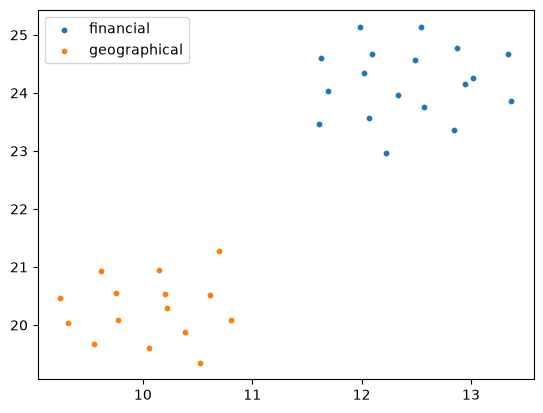

In [186]:
# plot the 2D embeddings by sense, using different colors and a legend indicating the sense
for sense in df.sense.unique():
    idxs = df.sense == sense
    plt.scatter(embeddings_2d[idxs, 0], embeddings_2d[idxs, 1], label=sense, s=10)
plt.legend()
plt.show()

This creates a neat separation between different clusters of the contextualized embeddings of "bank" in the final layer's embedding space.

#### 🔥 Brainstorming exercise 🔥

- Can you think of any potential uses BERT's ability to contextualize words' embeddings in your research, for example to study differences in word use across actors or domains?
- Do you think you could as well us the pretrained `bert-base-uncased` model loaded above? Why or why not?


### Predicting masked-out words

In [190]:
# Load the pre-trained model for masked language modeling
model = AutoModelForMaskedLM.from_pretrained(model_id)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [191]:
# Define the text with a masked token
text = "He was walking along the [MASK] of the river."

# Tokenize the input text
inputs = tokenizer(text, return_tensors="pt")

# Get the index of the masked token
masked_index = (inputs['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1].item()

In [192]:
# Predict the masked token
with torch.no_grad():
    outputs = model(**inputs)
    predictions = outputs.logits

In [193]:
predictions[0, masked_index].shape

torch.Size([30522])

In [199]:
# Get the log probabilities of the 10 best fitting words
log_probs = torch.log_softmax(predictions[0, masked_index], dim=-1)
top_10_log_probs, top_10_indices = torch.topk(log_probs, 10)

# Convert indices to tokens
top_10_tokens = tokenizer.convert_ids_to_tokens(top_10_indices.tolist())

# exponentiate log-probabilities to get probabilities back
top_10_probs = torch.exp(top_10_log_probs)

# Print the results
for token, prob in zip(top_10_tokens, top_10_probs):
    print(f"{prob.item():.4f}\t'{token}'")

0.5824	'bank'
0.1818	'banks'
0.1125	'edge'
0.0443	'side'
0.0175	'shore'
0.0046	'bottom'
0.0034	'bed'
0.0030	'surface'
0.0030	'shores'
0.0028	'##bank'


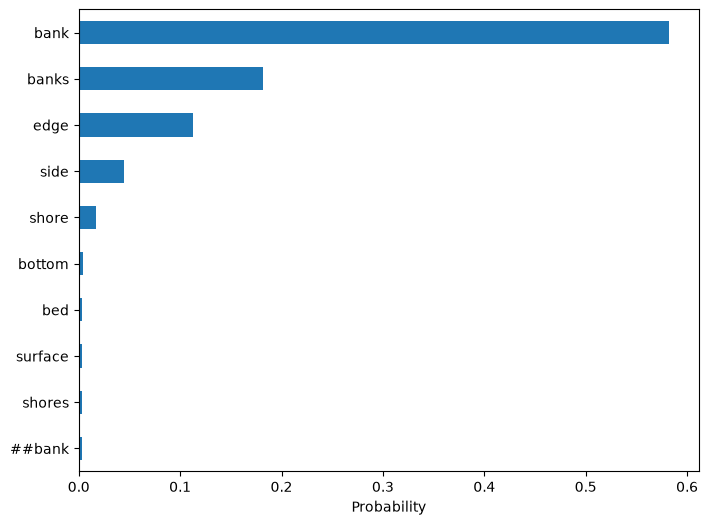

In [201]:
# Print the results
pd.Series(top_10_probs, index=top_10_tokens).sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.xlabel('Probability')
plt.show()

#### Example application: Studying gender bias in pre-trained models

In [206]:
# # Load the pre-trained model for masked language modeling
# model = AutoModelForMaskedLM.from_pretrained(model_id)

In [209]:
def get_topk_words(text):
    
    # Tokenize the input text
    inputs = tokenizer(text, return_tensors="pt")

    # Get the index of the masked token
    masked_index = (inputs['input_ids'] == tokenizer.mask_token_id).nonzero(as_tuple=True)[1].item()

    # Predict the masked token
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = outputs.logits

    # Get the log probabilities of the 10 best fitting words
    log_probs = torch.log_softmax(predictions[0, masked_index], dim=-1)
    top_10_log_probs, top_10_indices = torch.topk(log_probs, 10)

    # Convert indices to tokens
    top_10_tokens = tokenizer.convert_ids_to_tokens(top_10_indices.tolist())

    # Print the results
    out = pd.DataFrame({'token': top_10_tokens, 'log_prob': top_10_log_probs})
    out['prob'] = np.exp(out.log_prob)
    return out

In [210]:
get_topk_words('He was very [MASK].')

,token,log_prob,prob
0,good,-3.055780,0.047086
1,quiet,-3.167319,0.042116
2,beautiful,-3.588070,0.027652
3,serious,-3.673758,0.025381
4,handsome,-3.794044,0.022504
5,happy,-3.836723,0.021564
6,strong,-3.843157,0.021426
7,calm,-4.042289,0.017557
8,young,-4.057728,0.017288
9,angry,-4.095251,0.016652


In [211]:
get_topk_words('She was very [MASK].')

,token,log_prob,prob
0,beautiful,-2.502167,0.081907
1,quiet,-3.159199,0.042460
2,pretty,-3.184891,0.041383
3,good,-3.568262,0.028205
4,young,-3.631834,0.026468
5,happy,-3.723592,0.024147
6,tired,-3.917140,0.019898
7,strong,-3.982162,0.018645
8,calm,-4.088913,0.016757
9,serious,-4.262281,0.014090
